# Create Images of Enemy Sprite Explosions

In [15]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:60% !important; }</style>"))

Load in the sprite data

In [9]:

import re
from colors_map import *

sprites_files = ["uridium/src/explosion_sprites.asm"]
sprites_data = {}
sprites_bytes = {}
sprites_ram = {}
sprites_offset = {}
sprite_orientation = {}
sprite_ram = 0x5000
for sprites_file in sprites_files:
    input_file = open(sprites_file,'r')
    sprite_data = []
    sprite_bytes = ""
    for l in input_file.readlines():
        if "SPRITE" in l:
            if sprite_data:
                sprites_data[sprite_name] = sprite_data
                sprites_bytes[sprite_name] = sprite_bytes
                sprites_ram[sprite_name] = hex(sprite_ram)[2:].upper()
                sprite_ram += 0x40
            sprite_name = l[18:20].strip().upper()
            sprite_orientation[sprite_name] = (l[42:45],l[51:54],l[60:63],)
            sprites_offset[sprite_name] = l[18:20]
            sprite_data = []
            sprite_bytes = ""
            continue

        m = re.findall(r"[0-1]{24}",l)
        if not m:
            continue
        bits = m[0]
        sprite_line = []
        for i in range(0,23,2):
            bitpair = bits[i:i+2]
            sprite_line += [bitpair]
            sprite_line += [bitpair]
        sprite_data += [sprite_line]
        sprite_bytes += l[10:21]+'\n'
    if sprite_data:
        sprites_data[sprite_name] = sprite_data
        sprites_bytes[sprite_name] = sprite_bytes
        sprites_ram[sprite_name] = hex(sprite_ram)[2:].upper()

Function for actually drawing the sprite

In [3]:
from PIL import Image, ImageDraw, ImageColor, ImageFont
SPRITE_COLS = 24
SPRITE_ROWS = 21
CELL_WIDTH = 40
CELL_HEIGHT = 40


def paintSprite(sprite_data, colors):
    (background, background_text), (multicol0, multicol0_text), (multicol1,multicol1_text), (color, color_text) = colors
    colormap = {
        "00": background,
        "01": multicol0,
        "10": color,
        "11": multicol1,
    }
    text_colormap = {
        "00": background_text,
        "01": multicol0_text,
        "10": color_text,
        "11": multicol1_text,
    }
    
    image_width = CELL_WIDTH*SPRITE_COLS
    image_height = CELL_HEIGHT*SPRITE_ROWS
    img = Image.new( 'RGBA', (image_width+1, image_height+1))
    draw = ImageDraw.Draw(img)

    fnt = ImageFont.truetype("RobotoMono-Light.ttf", 40)
    bit_array = sprite_data
    # Remember that each bitpair in the bit_array is duplicated.
    # e.g. 01 appears as 01,01 so that we can treat each element as
    # a single bit.
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            pixel_color = ImageColor.getrgb(c64_to_rgb[colormap[bit]])
            X = x * CELL_WIDTH
            Y = y * CELL_HEIGHT
            draw.rectangle((X, Y, X+CELL_WIDTH, Y+CELL_HEIGHT), 
                           fill=pixel_color, outline="black")
            b = bit[(x%2)] # Get the correct side of the bitpair
            draw.text((X+10, Y-8), b, font=fnt, fill=text_colormap[bit])
    return img


In [5]:
byte_literals = """.BYTE
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
.BYTE 
"""

def generateSpriteDiagram(sprite_name, entry_num, colors):
    sprite_data = sprites_data[sprite_name]
    sprite_bytes = sprites_bytes[sprite_name]
    sprite_ram = sprites_ram[sprite_name]
    sprite_offset = sprites_offset[sprite_name]
    
    sprite_img = paintSprite(sprite_data, colors)

    img = Image.new('RGBA', (1530,900))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"MEANIE/EXPLOSION/{('0'+str(entry_num))[-2:]}"
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (35,194))

    # Sprite spec name
    label_text = f"SPEC:{sprite_name.ljust(14)}   OFFSET:${sprite_offset.upper()}  RAM:${sprite_ram}"
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size+20))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (80,-440))


    # Sprite orientation
    azimuth, roll, elevation = ("000","000","000")
    label_text = f"AZIMUTH:{azimuth}°    ELEVATION:{elevation}°    ROLL:{roll}°"
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size+20))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt.rotate(90,  expand=1)
    img.paste(label, (120,-440))

    # Color Label
    label_text = "BASE_COLOR: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * (label_fnt_size - 10)
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[2][0]])
    draw.rectangle([(210,6), (229,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (160,860))

    # MultiCol0 Label
    label_text = "MULTI_COLOR0: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[1][0]])
    draw.rectangle([(250,6), (269,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (490,860))

    # MultiCol1 Label
    label_text = "MULTI_COLOR1: "
    label_fnt_size = 30
    label_fnt = ImageFont.truetype("DepartureMono-Regular.otf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    pixel_color = ImageColor.getrgb(c64_to_rgb[colors[3][0]])
    draw.rectangle([(250,6), (269,29)], fill = pixel_color, outline="black")
    label = txt
    img.paste(label, (850,860))


    # Sprite byte literals
    label_text = byte_literals
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(sprite_bytes.split()) * (label_fnt_size+10)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="blue")
    label = txt
    img.paste(label, (1140,8))

    # Sprite bytes
    label_text = sprite_bytes
    label_fnt_size = 35
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt_height =  len(sprite_bytes.split()) * (label_fnt_size+10)
    txt = Image.new('RGBA', (txt_width, txt_height))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    label = txt
    img.paste(label, (1260,8))

    # Main Sprite image
    img.paste(sprite_img, (160,10))

    # Byte delimiter ticks
    draw = ImageDraw.Draw(img)
    vectors = [
        ((480,0), (480,10)), 
        ((800,0), (800,10)),
        #((450,850), (450,865)), 
        #((770,850), (770,865)),
    ]
    for start,end in vectors:
        draw.line((start,end), width=3, fill="black")
    return img

In [6]:
from colors_map import *
raw_level_color_schemes = """
        .BYTE M_GRAY1,M_GRAY3,M_ORANGE,M_YELLOW,M_ORANGE  ; Level 1
        .BYTE M_BLACK,M_GRAY1,M_LTBLUE,M_LTRED,M_RED      ; Level 2, Level 13
        .BYTE M_BROWN,M_ORANGE,M_ORANGE,M_LTGREEN,M_GREEN ; Level 3, Level 11
        .BYTE M_GRAY1,M_GRAY3,M_ORANGE,M_LTBLUE,M_BLUE    ; Level 4
        .BYTE M_GREEN,M_LTGREEN,M_ORANGE,M_LTBLUE,M_BLUE  ; Level 5
        .BYTE M_ORANGE,M_YELLOW,M_ORANGE,M_GRAY2,M_BLACK  ; Level 6
        .BYTE M_GRAY1,M_CYAN,M_LTGREEN,M_LTRED,M_RED      ; Level 7
        .BYTE M_BLACK,M_GRAY2,M_LTRED,M_LTBLUE,M_BLUE     ; Level 8
        .BYTE M_BLUE,M_LTBLUE,M_ORANGE,M_LTGREEN,M_GREEN  ; Level 9 , Level 14
        .BYTE M_GRAY1,M_GRAY2,M_GRAY2,M_LTRED,M_RED       ; Level 10
        .BYTE M_BROWN,M_ORANGE,M_ORANGE,M_LTGREEN,M_GREEN ; Level 3, Level 11
        .BYTE M_BLUE,M_CYAN,M_ORANGE,M_GRAY2,M_GRAY1      ; Level 12
        .BYTE M_BLACK,M_GRAY1,M_LTBLUE,M_LTRED,M_RED      ; Level 2, Level 13
        .BYTE M_BLUE,M_LTBLUE,M_ORANGE,M_LTGREEN,M_GREEN  ; Level 9 , Level 14
        .BYTE M_RED,M_LTRED,M_ORANGE,M_YELLOW,M_ORANGE    ; Level 15
"""
raw_level_color_schemes = [l[14:57].split(',') for l in raw_level_color_schemes.split('\n')][1:-1]
raw_level_color_schemes = [[x.strip() for x in l] for l in raw_level_color_schemes]
level_colors = [None]
for l in raw_level_color_schemes:
    colors = (color_constants[l[3]], "c64_white",color_constants[l[4]])
    level_colors += [colors]
level_colors[1]

('c64_yellow', 'c64_white', 'c64_orange')

In [7]:
!mkdir -p uridimine_diagrams

In [10]:
for level, colors in enumerate(level_colors):
    if not level:
        continue
    for entry_num, sprite_name in enumerate(sprites_data):
        if not sprite_name:
            continue
        ccolors = (
            # cell color, text color
            ("c64_gray3", "white"),
            (colors[0], "darkgray"),
            (colors[1], "gray"),
            (colors[2], "white"),
        )
        img = generateSpriteDiagram(sprite_name, sprites_offset[sprite_name].upper(), ccolors)
        img.save(f"uridimine_diagrams/{level}_{sprite_name}.png")


### Write out sprite images

In [11]:
from PIL import Image, ImageColor
SPRITE_COLS = 24
SPRITE_ROWS = 21
CELL_WIDTH = 40
CELL_HEIGHT = 40

def paintRawSprite(sprite, colors, verticalExpand=False):
    multicol0, multicol1,color = colors
    
    verticalExpansion = 2 if verticalExpand else 1
    SPRITE_COLS = 24
    SPRITE_ROWS = 21 * verticalExpansion

    colormap = {
        "01": multicol0,
        "10": color,
        "11": multicol1,
    }
    
    if sprite not in sprites_data:
        print(sprite)
        return
    
    image_width = SPRITE_COLS
    image_height = SPRITE_ROWS
    img = Image.new( 'RGBA', (image_width+1, image_height+1))
    pixels = img.load()

    bit_array = sprites_data[sprite]
    if verticalExpand:
        expanded_bit_array = []
        for a in bit_array:
            expanded_bit_array += [a,a]
        bit_array = expanded_bit_array
    
    for y, l in enumerate(bit_array):
        for x,bit in enumerate(l):
            if bit == "00":
                continue
            pixel_color = ImageColor.getrgb(c64_to_rgb[colormap[bit]])
            pixels[x,y] = pixel_color
    return img


In [12]:
!mkdir -p uridimine_sprites

In [96]:
from PIL import Image, ImageFilter, ImageColor
def addBlackOutline(img):
    stroke_radius = 5
    stroke_image = Image.new("RGBA", img.size, (0, 0, 0, 255))
    img_alpha = img.getchannel(3).point(lambda x: 255 if x>0 else 0)
    stroke_alpha = img_alpha.filter(ImageFilter.MaxFilter(stroke_radius))
    # optionally, smooth the result
    stroke_alpha = stroke_alpha.filter(ImageFilter.SMOOTH)
    stroke_image.putalpha(stroke_alpha)
    output = Image.alpha_composite(stroke_image, img)
    return output

In [102]:
resize = lambda img, scale: img.resize((int(img.width * scale), int(img.height * scale)), Image.NEAREST)
for i, colors in enumerate(level_colors):
    if not i:
        continue
    sprite_images = []
    for sprite_name in sprites_data:
        img = paintRawSprite(sprite_name, colors)
        img = resize(img,2)
        sprite_images += [img]
        if sprite_name:
            img.save(f"uridimine_sprites/{i}_{sprite_name}.png")
            addBlackOutline(resize(img,4)).save(f"uridimine_sprites/{i}_{sprite_name}_outlined.png")


## Create Image of Uridimine Launching

In [24]:
from PIL import Image
def get_surface_snippet(level=1, x_offset=600, y_offset = 0, width=1000, height = 200):
    img = Image.open(f"surfaces_raw/{level}.png")
    img = img.crop((x_offset, y_offset, x_offset + width, y_offset + height))
    img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
    return img

def make_shadow(img, color=(0x4a, 0x4a, 0x4a, 255)):
    d = img.getdata()
    new_image = []
    for item in d:
        if item[3] == 0:
            new_image.append(item)
        else:
            new_image.append(color)
    # update image data
    img.putdata(new_image)
    return img

def make_mask(i):
    img = i.copy()
    d = img.getdata()
    new_image = []
    for item in d:
        if item[3] != 0:
            new_image.append((0xff, 0xff, 0xff))
        else:
            new_image.append((0,0,0))
    # update image data
    img.putdata(new_image)
    return img

resize = lambda img: img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
add_offset = lambda a,b : [sum(x) for x in zip(a,b)]

In [21]:
from PIL import Image

img = Image.open("manta_sprites/9_MANTA1.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
manta = img.copy()
shadow = make_shadow(img)

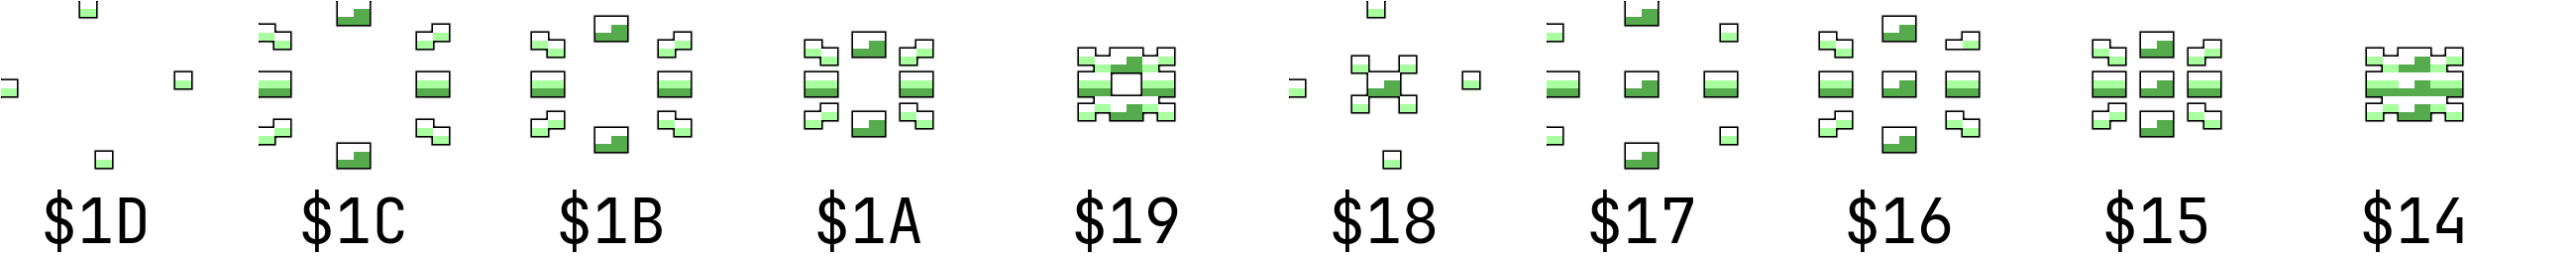

In [254]:
from PIL import Image, ImageDraw, ImageFont
level=9
offset = 260
frames = [f"{x:02X}" for x in range(0x1d,0x13,-1)]
img = Image.new('RGBA', (len(frames) * (offset), 260))
draw = ImageDraw.Draw(img)
x,y = 1,1
for sprite_name in frames:
    manta = Image.open(f"uridimine_sprites/{level}_{sprite_name}_outlined.png")
    img.paste(manta, (x,y),mask=manta)

    label_text = "$"+sprite_name
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", 62)
    label_x = x + 40
    label_y = y + 180
    draw.text((label_x, label_y), label_text, font=label_fnt, fill="black")
    
    x+= offset

img.save("uridimine/level9_launch_sequence.png")
img

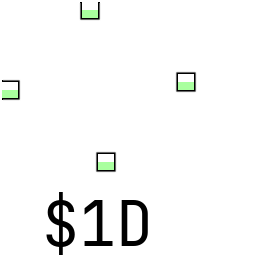

In [257]:
from PIL import Image, ImageDraw, ImageFont
level=9
offset = 260
frames = [f"{x:02X}" for x in range(0x1d,0x1e,1)]
img = Image.new('RGBA', (len(frames) * (offset), 260))
draw = ImageDraw.Draw(img)
x,y = 2,2
for sprite_name in frames:
    manta = Image.open(f"uridimine_sprites/{level}_{sprite_name}_outlined.png")
    img.paste(manta, (x,y),mask=manta)

    label_text = "$"+sprite_name
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", 62)
    label_x = x + 40
    label_y = y + 180
    draw.text((label_x, label_y), label_text, font=label_fnt, fill="black")
    
    x+= offset

img.save("uridimine/level9_launch_1D.png")
img

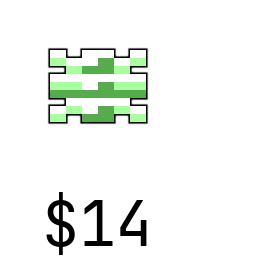

In [258]:
from PIL import Image, ImageDraw, ImageFont
level=9
offset = 260
frames = [f"{x:02X}" for x in range(0x14,0x15,1)]
img = Image.new('RGBA', (len(frames) * (offset), 260))
draw = ImageDraw.Draw(img)
x,y = 2,2
for sprite_name in frames:
    manta = Image.open(f"uridimine_sprites/{level}_{sprite_name}_outlined.png")
    img.paste(manta, (x,y),mask=manta)

    label_text = "$"+sprite_name
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", 62)
    label_x = x + 40
    label_y = y + 180
    draw.text((label_x, label_y), label_text, font=label_fnt, fill="black")
    
    x+= offset

img.save("uridimine/level9_launch_14.png")
img

## Create Image for Maybe Launch Uridimine

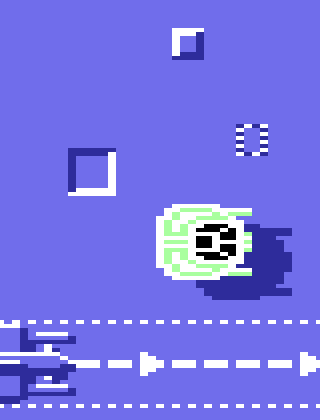

In [249]:
level = 9
diagram = get_surface_snippet(level=level, x_offset=965, y_offset = 25, width=80, height = 105)
mask = make_mask(diagram).convert('L')
manta_pos = (78,100)
shadow_offset = (20,10)

img = Image.open(f"manta_sprites/{level}_MANTA1.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)

manta = img.copy()
shadow = make_shadow(manta.copy(), color=(0x2e,0x2c,0x9b,255))
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.putalpha(mask)
diagram.paste(manta, manta_pos, mask=manta)

img = resize(diagram,2)
img.save("uridimine/level9_MaybeLaunchUridimine.png")
img

## Create Image of Mine Initial State - LaunchUridimine

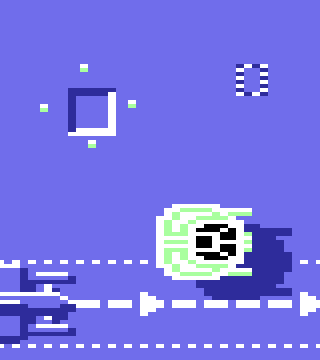

In [245]:
level = 9
diagram = get_surface_snippet(level=level, x_offset=965, y_offset = 40, width=80, height = 90)
mask = make_mask(diagram).convert('L')
manta_pos = (78,100)
shadow_offset = (20,10)

img = Image.open(f"manta_sprites/{level}_MANTA1.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)

manta = img.copy()
shadow = make_shadow(manta.copy(), color=(0x2e,0x2c,0x9b,255))
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.putalpha(mask)
diagram.paste(manta, manta_pos, mask=manta)

uridimine = Image.open(f"uridimine_sprites/{level}_1D.png")
diagram.paste(uridimine, (20,32), mask=uridimine)

img = resize(diagram,2)
img.save("uridimine/level9_LaunchUridimine.png")
img

## Create Image of Mine Creation - AnimateMineCreation

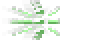

In [154]:
level=9
offset = 2
frames = [f"{x:02X}" for x in range(0x1d,0x13,-1)]
frames_with_alpha = list(zip(frames,range(0, 255, 30)))

img = Image.new('RGBA', (100, 40))
x,y = 0,0
for sprite_name,alpha in frames_with_alpha:
    manta = Image.open(f"uridimine_sprites/{level}_{sprite_name}.png")

    manta2 = manta.copy()
    manta2.putalpha(alpha)
    manta.paste(manta2, manta)

    img.paste(manta, (x,y),mask=manta)
    x+= offset

#img.save("uridimine/level9_launch_alpha.png")
launch_alpha = img
launch_alpha

In [15]:
!mkdir -p uridimine

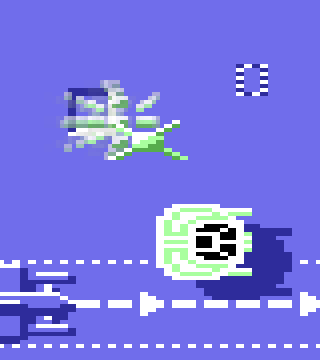

In [204]:
level = 9
diagram = get_surface_snippet(level=level, x_offset=965, y_offset = 40, width=80, height = 90)
mask = make_mask(diagram).convert('L')
manta_pos = (78,100)
shadow_offset = (20,10)

img = Image.open(f"manta_sprites/{level}_MANTA1.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)

manta = img.copy()
shadow = make_shadow(manta.copy(), color=(0x2e,0x2c,0x9b,255))
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.putalpha(mask)
diagram.paste(manta, manta_pos, mask=manta)

diagram.paste(launch_alpha, (20,40), mask=launch_alpha)

uridimine = Image.open(f"uridimine_sprites/{level}_11.png")
diagram.paste(uridimine, (50,50), mask=uridimine)

img = resize(diagram,2)
img.save("uridimine/level9_launch.png")
img

## Create Image of Uridimine Chasing - MineSeeksManta

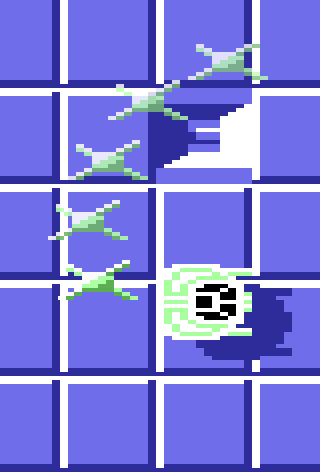

In [222]:
def add_alpha(img, alpha):
    img2 = img.copy()
    img2.putalpha(alpha)
    img.paste(img2, img)
    return img

level = 9
diagram = get_surface_snippet(level=level, x_offset=265, y_offset = 10, width=80, height = 118)
mask = make_mask(diagram).convert('L')
manta_pos = (78,130)
shadow_offset = (20,10)

img = Image.open(f"manta_sprites/{level}_MANTA1.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)

manta = img.copy()
shadow = make_shadow(manta.copy(), color=(0x2e,0x2c,0x9b,255))
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.putalpha(mask)
diagram.paste(manta, manta_pos, mask=manta)

uridimine = Image.open(f"uridimine_sprites/{level}_11.png")
uridimine = add_alpha(uridimine,190)
diagram.paste(uridimine, (90,10), mask=uridimine)

uridimine = Image.open(f"uridimine_sprites/{level}_11.png")
uridimine = add_alpha(uridimine,200)
diagram.paste(uridimine, (50,30), mask=uridimine)

uridimine = Image.open(f"uridimine_sprites/{level}_11.png")
uridimine = add_alpha(uridimine,210)
diagram.paste(uridimine, (30,60), mask=uridimine)

uridimine = Image.open(f"uridimine_sprites/{level}_11.png")
uridimine = add_alpha(uridimine,220)
diagram.paste(uridimine, (20,90), mask=uridimine)

uridimine = Image.open(f"uridimine_sprites/{level}_11.png")
uridimine = add_alpha(uridimine,250)
diagram.paste(uridimine, (25,120), mask=uridimine)

img = resize(diagram,2)
img.save("uridimine/level9_seek.png")
img

## Uridimine Explodes

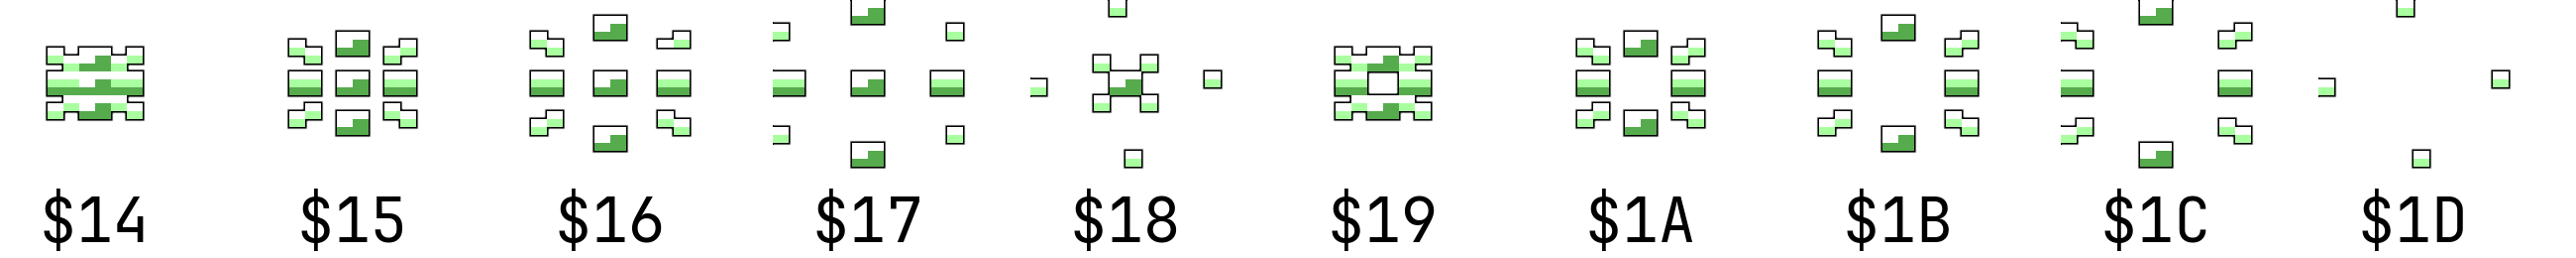

In [259]:
from PIL import Image, ImageDraw, ImageFont
level=9
offset = 260
frames = [f"{x:02X}" for x in range(0x14,0x1e)]
img = Image.new('RGBA', (len(frames) * (offset), 260))
draw = ImageDraw.Draw(img)
x,y = 0,0
for sprite_name in frames:
    manta = Image.open(f"uridimine_sprites/{level}_{sprite_name}_outlined.png")
    img.paste(manta, (x,y),mask=manta)

    label_text = "$"+sprite_name
    label_fnt = ImageFont.truetype("JetBrainsMono-Regular.ttf", 62)
    label_x = x + 40
    label_y = y + 180
    draw.text((label_x, label_y), label_text, font=label_fnt, fill="black")
    
    x+= offset

img.save(f"uridimine/level{level}_uridimine_explodes_sequence.png")
img

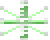

In [229]:
level=9
offset = 0
frames = [f"{x:02X}" for x in range(0x14,0x1d)]
frames_with_alpha = list(zip(frames,range(100, 255, 20)))

img = Image.new('RGBA', (50, 40))
x,y = 0,0
for sprite_name,alpha in frames_with_alpha:
    manta = Image.open(f"uridimine_sprites/{level}_{sprite_name}.png")

    manta2 = manta.copy()
    manta2.putalpha(alpha)
    manta.paste(manta2, manta)

    img.paste(manta, (x,y),mask=manta)
    x+= offset

#img.save("uridimine/level9_launch_alpha.png")
launch_alpha = img
launch_alpha

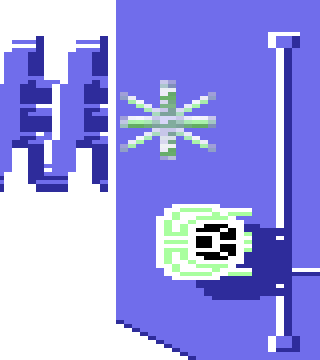

In [236]:
level = 9
diagram = get_surface_snippet(level=level, x_offset=2565, y_offset = 40, width=80, height = 90)
mask = make_mask(diagram).convert('L')
manta_pos = (78,100)
shadow_offset = (20,10)

img = Image.open(f"manta_sprites/{level}_MANTA1.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)

manta = img.copy()
shadow = make_shadow(manta.copy(), color=(0x2e,0x2c,0x9b,255))
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.putalpha(mask)
diagram.paste(manta, manta_pos, mask=manta)

diagram.paste(launch_alpha, (60,40), mask=launch_alpha)

img = resize(diagram,2)
img.save(f"uridimine/level{level}_explodes.png")
img

# Scratchpad